In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
from anndata import AnnData

import random
import leidenalg
import louvain
import time
import math

In [2]:
import numpy as np

def generate_cell_type_params(num_cell_types, mean_range=(5, 20), dispersion_range=(1, 5), amplitude_scalar = (0,1)):
    """
    Generate a list of (mean_expression, dispersion) tuples for each cell type.

    Parameters:
    - num_cell_types: Number of cell types.
    - mean_range: A tuple specifying the range for mean expression values.
    - dispersion_range: A tuple specifying the range for dispersion values.

    Returns:
    - cell_type_params: A list of (mean_expression, dispersion) tuples.
    """
    cell_type_params = []
    for _ in range(num_cell_types):
        mean_expression = np.random.uniform(*mean_range)
        dispersion = np.random.uniform(*dispersion_range)
        amplitude = np.random.uniform(*amplitude_scalar)
        cell_type_params.append((mean_expression, dispersion, amplitude))
    return cell_type_params

def assign_cell_counts(num_cell_types, total_cells, concentration=1.0):
    """
    Assign a random number of cells to each cell type using a Dirichlet distribution.

    Parameters:
    - num_cell_types: Number of cell types.
    - total_cells: Total number of cells to be distributed.
    - concentration: Concentration parameter for the Dirichlet distribution.

    Returns:
    - cells_per_type: A list with the number of cells assigned to each cell type.
    """
    proportions = np.random.dirichlet([concentration] * num_cell_types)
    cells_per_type = np.round(proportions * total_cells).astype(int)
    
    # Adjust to ensure the total number of cells matches exactly
    difference = total_cells - np.sum(cells_per_type)
    if difference != 0:
        adjustment_indices = np.random.choice(num_cell_types, abs(difference), replace=True)
        adjustment = np.sign(difference)
        for idx in adjustment_indices:
            cells_per_type[idx] += adjustment
    
    return cells_per_type

def simulate_counts(num_genes, num_cells, num_cell_types, num_rhythmic_genes, timepoints, concentration, circ_noise_sd):
    """
    Simulate sparse single-cell RNA-seq counts with distinct distributions for each cell type.

    Parameters:
    - num_genes: Number of genes.
    - num_cells: Number of cells.
    - num_cell_types: Number of distinct cell types.

    Returns:
    - matrix: matrix of gene expression counts.
    - cell_type_membership: vector indicating the cell type for each cell.

    """

    # Initialize the count matrix
    counts = np.zeros((num_genes+num_rhythmic_genes, num_cells))
    cell_type_membership = np.zeros(num_cells, dtype=int)

    #generate phases for rhythmic genes:
    phases = []
    for i in range(num_rhythmic_genes):
        if i < 3:
            phases.append(np.random.uniform(-.5, .5))
        elif (i in [3, 4, 5]):
            phases.append(np.random.uniform(3*np.pi/2-.5, 3*np.pi/2+ .5))
        elif (i in [6, 7, 8, 9, 10, 11, 12]) :
            phases.append(np.random.uniform(np.pi-.5, np.pi+.5))
        else:
            phases.append(np.random.uniform(0, 2*np.pi))
        


   # Assign a random number of cells to each cell type
    cells_per_type = assign_cell_counts(num_cell_types, num_cells, concentration)

    # Track the starting index for each cell type
    start_idx = 0
    
    for idx, (mean_expression, dispersion, amplitude_scalar) in enumerate(cell_type_params):
        # Calculate size parameter for negative binomial (equivalent to number of trials)
        size = (mean_expression ** 2) / (dispersion - mean_expression) if dispersion > mean_expression else 1
        
         # Determine the number of cells for this type
        end_idx = start_idx + cells_per_type[idx]
        
        # Generate negative binomial counts for this cell type
        counts[0:num_genes, start_idx:end_idx] = np.random.negative_binomial(
            size, size / (size + mean_expression), (end_idx - start_idx, num_genes)
        ).T

         # Assign cell type membership
        cell_type_membership[start_idx:end_idx] = idx
        
        #Generate the rhythmic counts:
        for j, phase in enumerate(phases):
            counts[num_genes+j, start_idx:end_idx] = amplitude_scalar * np.cos(np.pi/12 * timepoints[start_idx:end_idx] - phase) + mean_expression + np.random.normal(0, circ_noise_sd, end_idx-start_idx )
        
        # Move the starting index for the next cell type
        start_idx = end_idx
    return counts.T, cell_type_membership



**Create Synthetic Data**

In [3]:
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Create an AnnData object
adata = sc.AnnData()

# Define the number of cells and genes
n_cells = 5000
n_genes = 1000
# offset_multiplier = 8 #How different are the cell types
n_cell_types = 10      #Number of cell types
n_subjects = 14       #Number of subjects
sparsity_level = 0.0  #percent of the counts that are zeros
n_rhythmic_genes = 12 #How many rhythmic genes to generate
noise = np.random.normal(0, 0, (n_cells, n_genes+n_rhythmic_genes)) #Normal noise applied to every count
concentration=1. #How variable are the number of cells in each cell type?
circ_noise_sd = .1 #stand. dev. of normal noise applied to rhythmic genes

timepoints = np.repeat([0, 3, 6, 9, 12,15,18,21], math.ceil(n_cells/8)) #Timepoints of each subject
timepoints = timepoints[0:n_cells] #makes sure right length
subjects = np.repeat(range(n_subjects), math.ceil(n_cells/n_subjects))
subjects = subjects[0:n_cells]


#Generate cell type params:
cell_type_params = generate_cell_type_params(n_cell_types, dispersion_range=(1, 5), mean_range=(5,15), amplitude_scalar=(1, 2))

# Simulate the sparse counts
sparse_counts, cell_type_membership = simulate_counts(n_genes, n_cells, n_cell_types, n_rhythmic_genes, timepoints,concentration, circ_noise_sd )

# Simulate gene expression data
gene_expression_data = sparse_counts + noise  # Negative Binomial distribution for sparsity

#Make anndata obj
adata = sc.AnnData(X=gene_expression_data)



Introduce Sparsity with Zero Masking

In [4]:
# Introduce sparsity
zero_mask = np.random.rand(n_cells, n_genes+n_rhythmic_genes) < sparsity_level
adata.X[zero_mask] = 0
assert(zero_mask.shape == adata.X.shape)

In [5]:
test = adata.X

**Plot Synthetic Genes**

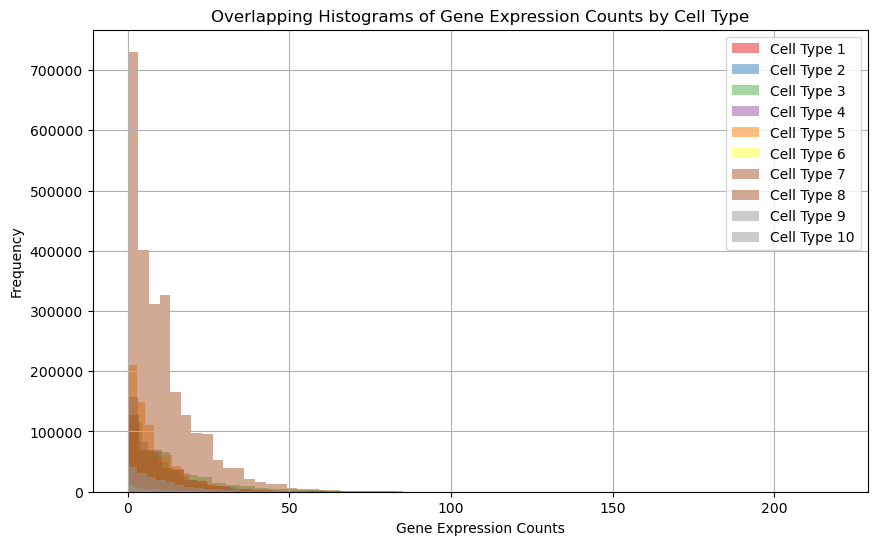

In [6]:
# Plot overlapping histograms for each cell type
plt.figure(figsize=(10, 6))
colors = plt.cm.Set1(np.linspace(0, 1, n_cell_types))  # Using 'Set1' for more distinct colors

for cell_type in range(n_cell_types):
    # Select counts for the current cell type
    cell_type_counts = adata.X[cell_type_membership == cell_type, :].flatten()
    
    # Plot histogram
    plt.hist(cell_type_counts, bins=50, alpha=0.5, color=colors[cell_type], label=f'Cell Type {cell_type + 1}')

plt.xlabel('Gene Expression Counts')
plt.ylabel('Frequency')
plt.title('Overlapping Histograms of Gene Expression Counts by Cell Type')
plt.legend()
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


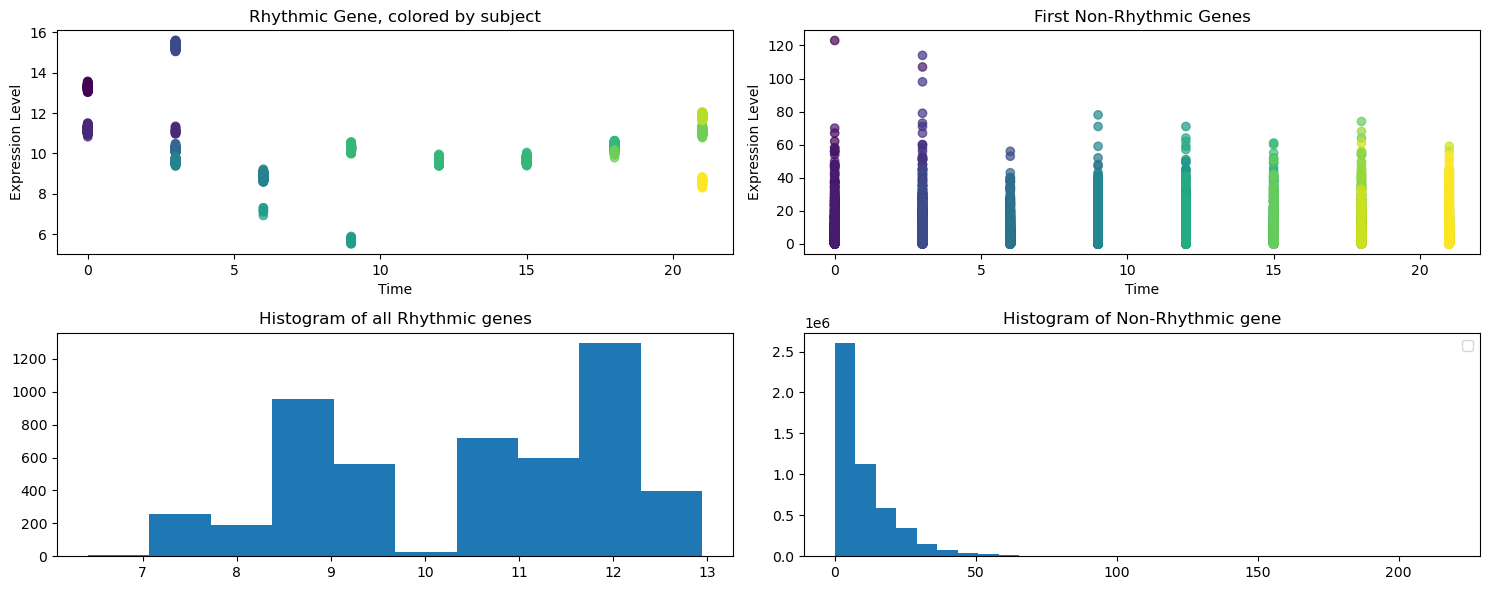

In [7]:
import matplotlib.pyplot as plt
# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(15, 6))

# Plot rhythmic genes
axes[0, 0].set_title('Rhythmic Gene, colored by subject')
for i in range(n_genes, n_genes+1):
    axes[0,0].scatter(timepoints, adata.X[:, i], label=f'Gene_{i + 1}', c = cell_type_membership, alpha = 0.7)
axes[0, 0].set_xlabel('Time')
axes[0,0].set_ylabel('Expression Level')

# Plot non-rhythmic genes
axes[0, 1].set_title('First Non-Rhythmic Genes')
for i in range(0, 1):
    axes[0, 1].scatter(timepoints, adata.X[:, i], label=f'Gene_{i + 1}', c = subjects, alpha = 0.7)
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Expression Level')

axes[1,0].set_title('Histogram of all Rhythmic genes')
axes[1,0].hist(adata.X[:, n_genes+n_rhythmic_genes-1].flatten())

axes[1,1].set_title('Histogram of Non-Rhythmic gene')
axes[1,1].hist(adata.X[:, 0:n_genes].flatten(), bins = 30)
axes[1,1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


**Add cell identity, subject, and timepoint variables to the adata objects**

In [8]:
cell_identities = [f'Cell_{i:.2f}' for i in cell_type_membership]
subjects_obs = [f's_{i}' for i in subjects]

# Add the 'Cell_Identity' column to adata.obs
adata.obs['Cell_Identity'] = cell_identities
adata.obs['subject'] = subjects_obs
adata.obs['subject_num'] = subjects
adata.obs['timepoints'] = timepoints

assert(len(cell_identities) == n_cells)
assert(len(subjects_obs) == n_cells)

/opt/miniconda3/envs/native/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


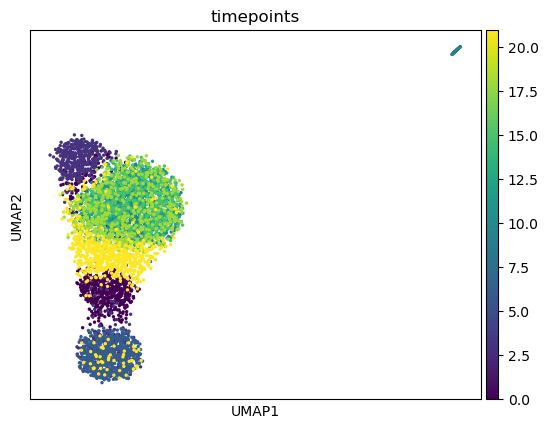

In [9]:
# # If UMAP has not been computed, compute it (optional)
# sc.pp.normalize_total(adata2, target_sum=1e4)

# # Log-transform the data
# # sc.pp.log1p(adata2)

# # # Identify highly variable genes (optional)
# # sc.pp.highly_variable_genes(adata2, min_mean=0.0125, max_mean=3, min_disp=0.5)

# # # Subset to highly variable genes (optional)
# # adata2 = adata2[:, adata2.var.highly_variable]

# # Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata)

sc.pp.neighbors(adata, use_rep = 'X_pca', n_neighbors= 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color='timepoints')  # replace 'gene1', 'gene2' with the names of genes or metadata you want to color by


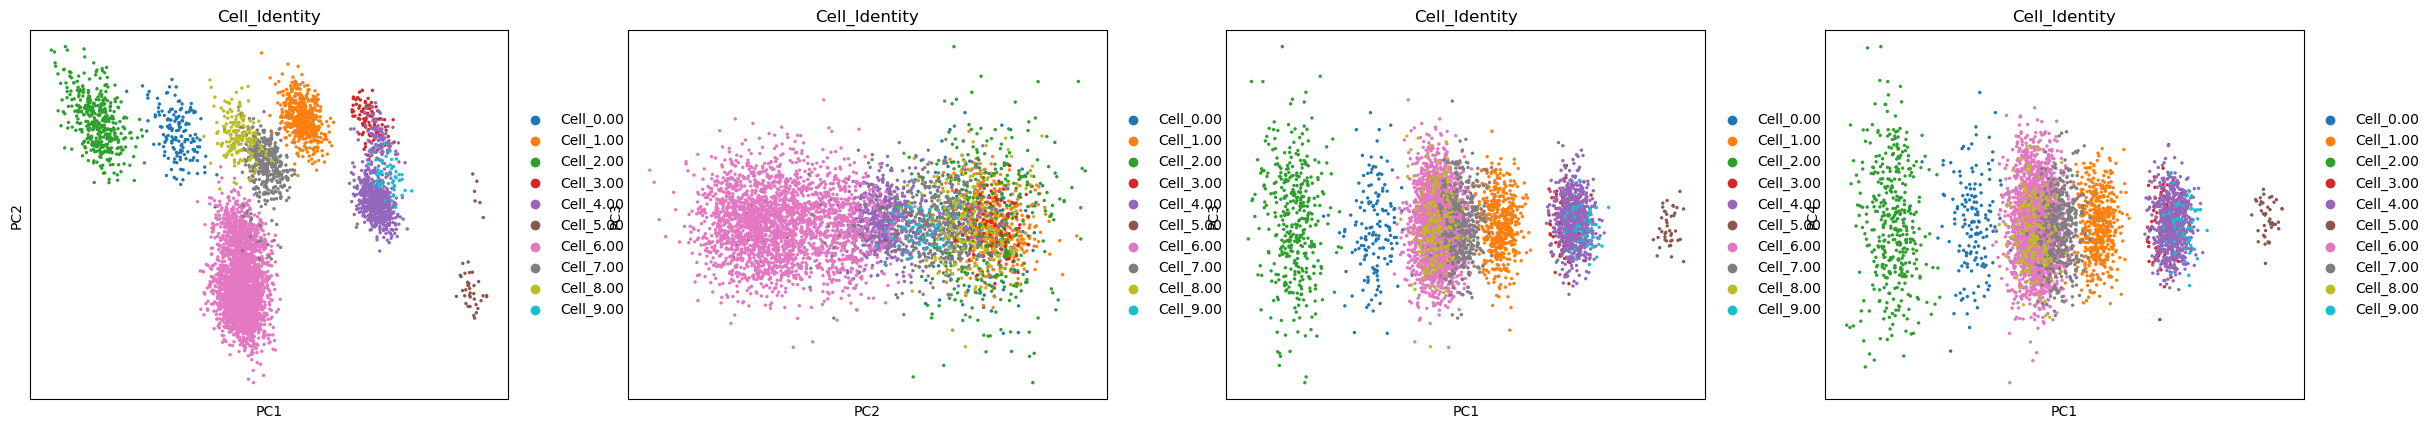

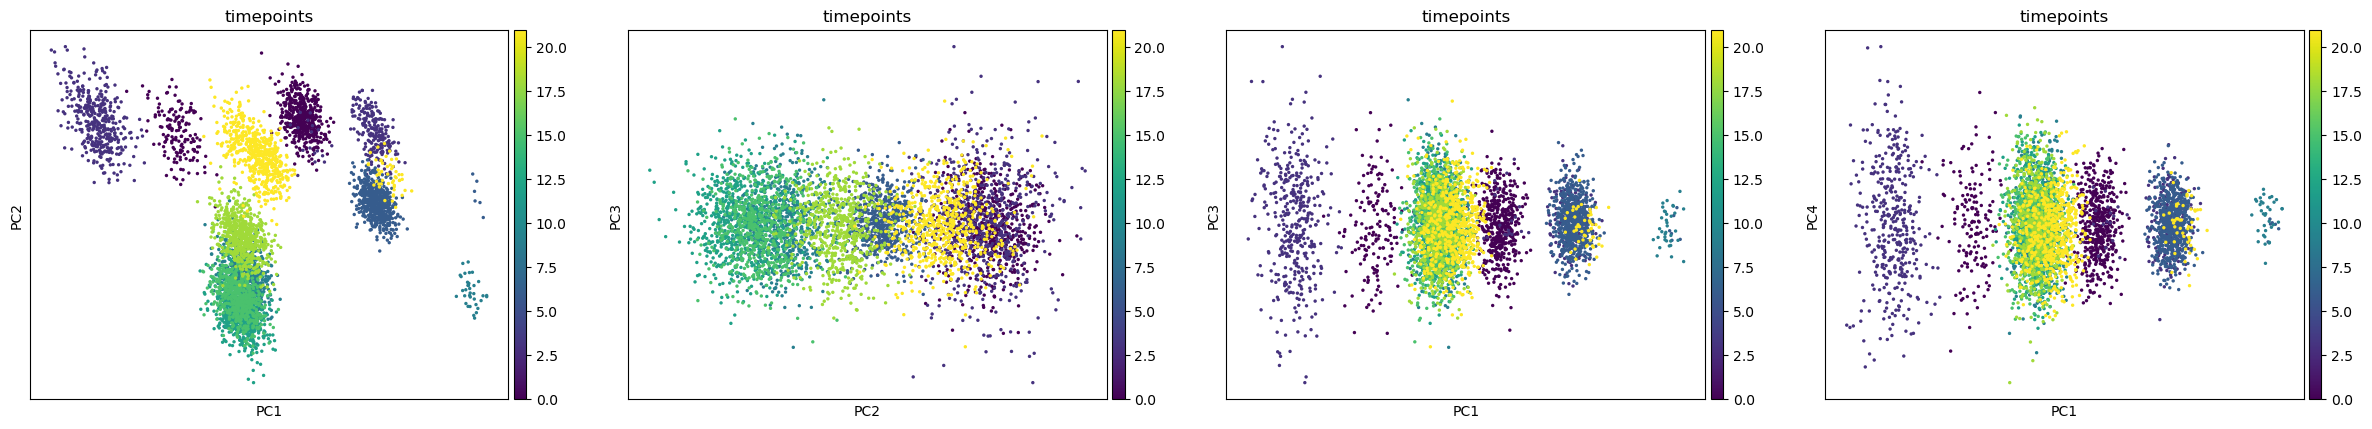

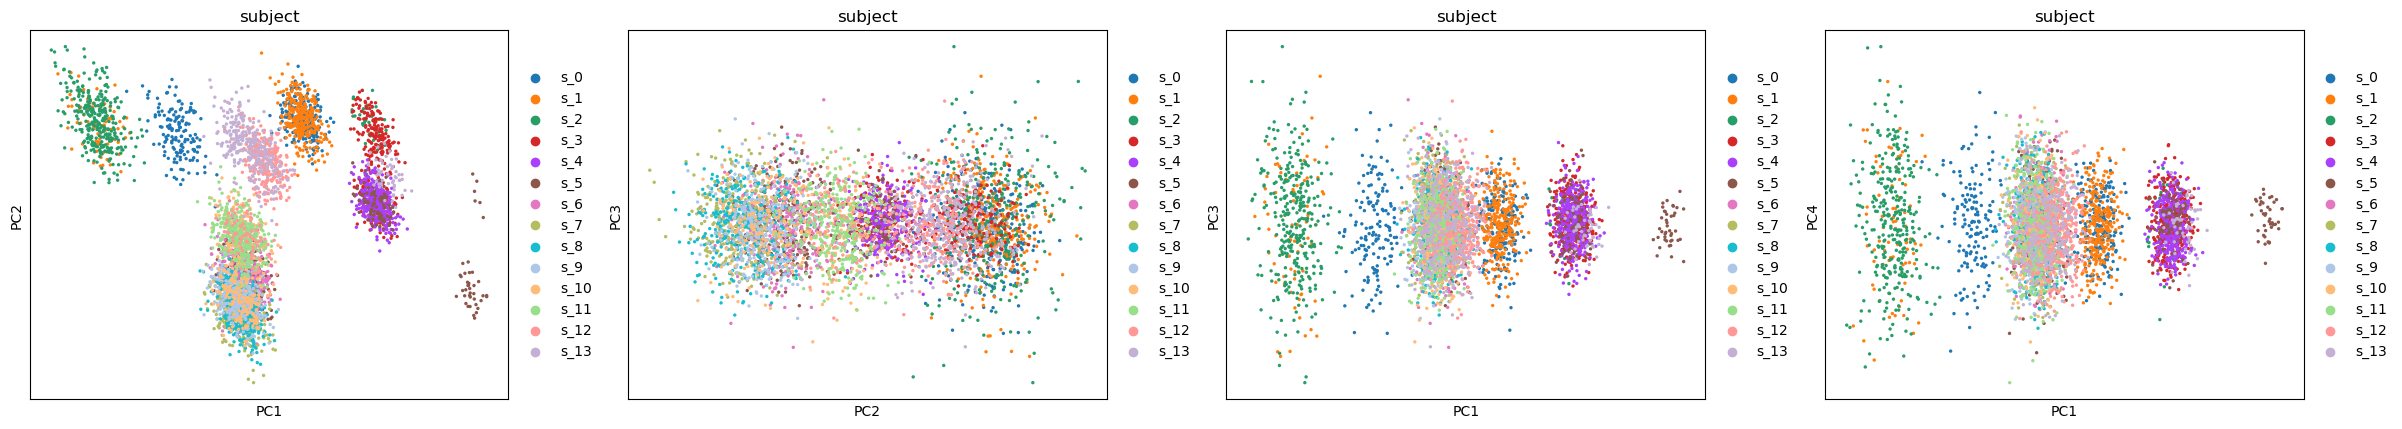

In [10]:
import warnings
# Suppress specific warnings
# Suppress all warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sc.pp.pca(adata)
    pcs_to_plot = ['1,2', '2,3', '1,3', '1, 4']

    # Plot PCA for the selected PCs
    sc.pl.pca(adata, color='Cell_Identity', components=pcs_to_plot, show=True)
    sc.pl.pca(adata, color='timepoints', components=pcs_to_plot, show=True)
    sc.pl.pca(adata, color='subject', components=pcs_to_plot, show=True)



**Create All Cell Pseudobulk**

In [11]:
# num_subjects = len(np.unique(adata2.obs['subject']))
# pseudobulk_samples = np.zeros((num_subjects, n_genes+n_new_genes))

# # Group by subjects and sum the expression counts
# grouped = adata2.obs.groupby('subject_num').indices

# for sub, cell_indices in grouped.items():
#     pseudobulk_samples[sub, :] = adata2.X[cell_indices, :].sum(axis=0)

# # Create a new AnnData object for pseudobulk samples
# adata_pseudobulk = AnnData(X=pseudobulk_samples)
# adata_pseudobulk.obs['subject'] = np.unique(subjects)
# adata_pseudobulk.obs['timepoints'] = np.unique(timepoints)
# # Print the shape of the pseudobulk samples
# print("Pseudobulk samples shape:", adata_pseudobulk.X.shape)

# # Display the pseudobulk data
# print("Pseudobulk data:")
# print(adata_pseudobulk.X)

In [12]:

# # Create a figure with two subplots (1 row, 2 columns)
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# # Get the number of unique membership values
# unique_memberships = np.unique(subjects)
# num_colors = len(unique_memberships)

# # Generate a random permutation of color indices
# color_indices = np.random.permutation(num_colors)

# # Create a discrete colormap with randomly ordered colors
# cmap = plt.cm.get_cmap('hsv', num_colors)
# colors = cmap(color_indices)
# random_cmap = ListedColormap(colors)

# # Define the boundaries and norm for the colormap
# bounds = np.arange(-0.5, num_colors + 0.5, 1)
# norm = BoundaryNorm(bounds, random_cmap.N)

# # Plot rhythmic genes
# axes[0].set_title('Example Rhtymic Gene, all-cell pseudobulk, colored by subject (1 color per dot)')
# for i in range(n_genes, n_genes+1):
#     scatter = axes[0].scatter( adata_pseudobulk.obs['timepoints'], adata_pseudobulk.X[:, i],c = adata_pseudobulk.obs['subject'], cmap= random_cmap, label=f'Gene_{i + 1}')
# # Adding a colorbar
# cbar = plt.colorbar(scatter, ticks=np.arange(num_colors))
# cbar.set_label('Membership')

# axes[0].set_xlabel('Time')
# axes[0].set_ylabel('Expression Level')

# # Plot non-rhythmic genes
# axes[1].set_title('First 10 Non-Rhythmic Genes')
# for i in range(0, n_genes):
#     axes[1].scatter(adata_pseudobulk.obs['timepoints'], adata_pseudobulk.X[:, i], label=f'Gene_{i + 1}')
# axes[1].set_xlabel('Time')
# axes[1].set_ylabel('Expression Level')
# #axes[1].legend()

# # Adjust layout to prevent overlap
# plt.tight_layout()

# # Show the plot
# plt.show()
# plt.hist(adata_pseudobulk.X[:, 1])

In [13]:
from scanpy import _utils
import importlib
import warnings
from scanpy import logging as logg
from scipy import sparse
# from scanpy.tools._compat import old_positionals
from scanpy._utils import _choose_graph
from scanpy.tools._utils_clustering import rename_groups, restrict_adjacency
from natsort import natsorted
from collections.abc import Sequence
from types import MappingProxyType
from scipy.sparse import spmatrix
from collections.abc import Mapping, Sequence

try:
    from leidenalg.VertexPartition import MutableVertexPartition
except ImportError:

    class MutableVertexPartition:
        pass

    MutableVertexPartition.__module__ = "leidenalg.VertexPartition"
try:
    from louvain.VertexPartition import MutableVertexPartition
except ImportError:

    class MutableVertexPartition:
        pass

    MutableVertexPartition.__module__ = "louvain.VertexPartition"

from typing import TYPE_CHECKING, Literal, Any

#interface my custom clustering with scanpy:
def ccdCluster_leiden(
    adata: AnnData,
    emat,
    refmat,
    resolution: float = 1,
    *,
    restrict_to: tuple[str, Sequence[str]] | None = None,
    random_state: _utils.AnyRandom = 0,
    key_added: str = "louvainccd",
    adjacency: sparse.spmatrix | None = None,
    directed: bool | None = None,
    use_weights: bool = True,
    n_iterations: int = -1,
    partition_type: type[MutableVertexPartition] | None = None,
    neighbors_key: str | None = None,
    obsp: str | None = None,
    copy: bool = False,
    flavor: Literal["leidenalg", "ipgraph"] = "leidenalg",
    **clustering_args,
) -> AnnData | None:
    """\
    Cluster cells into subgroups [Traag18]_.

    Cluster cells using the Leiden algorithm [Traag18]_,
    an improved version of the Louvain algorithm [Blondel08]_.
    It has been proposed for single-cell analysis by [Levine15]_.

    This requires having ran :func:`~scanpy.pp.neighbors` or
    :func:`~scanpy.external.pp.bbknn` first.

    Parameters
    ----------
    adata
        The annotated data matrix.
    resolution
        A parameter value controlling the coarseness of the clustering.
        Higher values lead to more clusters.
        Set to `None` if overriding `partition_type`
        to one that doesn’t accept a `resolution_parameter`.
    random_state
        Change the initialization of the optimization.
    restrict_to
        Restrict the clustering to the categories within the key for sample
        annotation, tuple needs to contain `(obs_key, list_of_categories)`.
    key_added
        `adata.obs` key under which to add the cluster labels.
    adjacency
        Sparse adjacency matrix of the graph, defaults to neighbors connectivities.
    directed
        Whether to treat the graph as directed or undirected.
    use_weights
        If `True`, edge weights from the graph are used in the computation
        (placing more emphasis on stronger edges).
    n_iterations
        How many iterations of the Leiden clustering algorithm to perform.
        Positive values above 2 define the total number of iterations to perform,
        -1 has the algorithm run until it reaches its optimal clustering.
        2 is faster and the default for underlying packages.
    partition_type
        Type of partition to use.
        Defaults to :class:`~leidenalg.RBConfigurationVertexPartition`.
        For the available options, consult the documentation for
        :func:`~leidenalg.find_partition`.
    neighbors_key
        Use neighbors connectivities as adjacency.
        If not specified, leiden looks .obsp['connectivities'] for connectivities
        (default storage place for pp.neighbors).
        If specified, leiden looks
        .obsp[.uns[neighbors_key]['connectivities_key']] for connectivities.
    obsp
        Use .obsp[obsp] as adjacency. You can't specify both
        `obsp` and `neighbors_key` at the same time.
    copy
        Whether to copy `adata` or modify it inplace.
    flavor
        Which package's implementation to use.
    **clustering_args
        Any further arguments to pass to :func:`~leidenalg.find_partition` (which in turn passes arguments to the `partition_type`)
        or :meth:`igraph.Graph.community_leiden` from `igraph`.

    Returns
    -------
    Returns `None` if `copy=False`, else returns an `AnnData` object. Sets the following fields:

    `adata.obs['leiden' | key_added]` : :class:`pandas.Series` (dtype ``category``)
        Array of dim (number of samples) that stores the subgroup id
        (``'0'``, ``'1'``, ...) for each cell.

    `adata.uns['leiden']['params']` : :class:`dict`
        A dict with the values for the parameters `resolution`, `random_state`,
        and `n_iterations`.
    """
    if flavor not in {"igraph", "leidenalg"}:
        raise ValueError(
            f"flavor must be either 'igraph' or 'leidenalg', but '{flavor}' was passed"
        )
    igraph_spec = importlib.util.find_spec("igraph")
    if igraph_spec is None:
        raise ImportError(
            "Please install the igraph package: `conda install -c conda-forge igraph` or `pip3 install igraph`."
        )
    if flavor == "igraph":
        if directed:
            raise ValueError(
                "Cannot use igraph's leiden implemntation with a directed graph."
            )
        if partition_type is not None:
            raise ValueError(
                "Do not pass in partition_type argument when using igraph."
            )
    else:
        try:
            import leidenalg

            msg = 'Use of leidenalg is discouraged and will be deprecated in the future.  Please use `flavor="igraph"` `n_iterations=2` to achieve similar results.  `directed` must also be `False` to work with `igraph`\'s implementation.'
            warnings.warn(msg, FutureWarning)
        except ImportError:
            raise ImportError(
                "Please install the leiden algorithm: `conda install -c conda-forge leidenalg` or `pip3 install leidenalg`."
            )
    clustering_args = dict(clustering_args)

    start = logg.info("running Leiden ccd clustering")
    adata = adata.copy() if copy else adata
    # are we clustering a user-provided graph or the default AnnData one?
    if adjacency is None:
        adjacency = _utils._choose_graph(adata, obsp, neighbors_key)
    if restrict_to is not None:
        restrict_key, restrict_categories = restrict_to
        adjacency, restrict_indices = restrict_adjacency(
            adata,
            restrict_key,
            restrict_categories=restrict_categories,
            adjacency=adjacency,
        )
    # Prepare find_partition arguments as a dictionary,
    # appending to whatever the user provided. It needs to be this way
    # as this allows for the accounting of a None resolution
    # (in the case of a partition variant that doesn't take it on input)
    clustering_args["n_iterations"] = n_iterations
    #if resolution is not None:
        #clustering_args["resolution_parameter"] = resolution
    if flavor == "leidenalg":
        directed = True if directed is None else directed
        g = _utils.get_igraph_from_adjacency(adjacency, directed=directed)
        if partition_type is None:
            partition_type = leidenalg.ccdModularityVertexPartition
        if use_weights:
            clustering_args["weights"] = np.array(g.es["weight"]).astype(np.float64)
        clustering_args["seed"] = random_state
        part = leidenalg.find_partition(g, partition_type, emat, refmat, **clustering_args)
    else:
        g = _utils.get_igraph_from_adjacency(adjacency, directed=False)
        if use_weights:
            clustering_args["weights"] = "weight"
        clustering_args.setdefault("objective_function", "modularity")
        with _utils.set_igraph_random_state(random_state):
            part = g.community_leiden(**clustering_args)
    # store output into adata.obs
    groups = np.array(part.membership)
    if restrict_to is not None:
        if key_added == "leidenccd":
            key_added += "_R"
        groups = rename_groups(
            adata,
            key_added=key_added,
            restrict_key=restrict_key,
            restrict_categories=restrict_categories,
            restrict_indices=restrict_indices,
            groups=groups,
        )
    adata.obs[key_added] = pd.Categorical(
        values=groups.astype("U"),
        categories=natsorted(map(str, np.unique(groups))),
    )
    # store information on the clustering parameters
    adata.uns["louvainccd"] = {}
    adata.uns["leidenccd"]["params"] = dict(
        resolution=resolution,
        random_state=random_state,
        n_iterations=n_iterations,
    )
    logg.info(
        "    finished",
        time=start,
        deep=(
            f"found {len(np.unique(groups))} clusters and added\n"
            f"    {key_added!r}, the cluster labels (adata.obs, categorical)"
        ),
    )
    return (adata, g )

def cluster_louvain(
    adata: AnnData,
    emat,
    refmat,
    sample_ids = None,
    resolution: float | None = None,
    *,
    random_state: _utils.AnyRandom = 0,
    restrict_to: tuple[str, Sequence[str]] | None = None,
    key_added: str = "louvainccd",
    adjacency: spmatrix | None = None,
    flavor: Literal["vtraag", "igraph", "rapids"] = "vtraag",
    directed: bool = False,
    use_weights: bool = False,
    partition_type: type[MutableVertexPartition] | None = None,
    partition_kwargs: Mapping[str, Any] = MappingProxyType({}),
    neighbors_key: str | None = None,
    obsp: str | None = None,
    copy: bool = False,
) -> AnnData | None:
    """\
    Cluster cells into subgroups [Blondel08]_ [Levine15]_ [Traag17]_.

    Cluster cells using the Louvain algorithm [Blondel08]_ in the implementation
    of [Traag17]_. The Louvain algorithm has been proposed for single-cell
    analysis by [Levine15]_.

    This requires having ran :func:`~scanpy.pp.neighbors` or
    :func:`~scanpy.external.pp.bbknn` first,
    or explicitly passing a ``adjacency`` matrix.

    Parameters
    ----------
    adata
        The annotated data matrix.
    resolution
        For the default flavor (``'vtraag'``) or for ```RAPIDS```, you can provide a
        resolution (higher resolution means finding more and smaller clusters),
        which defaults to 1.0.
        See “Time as a resolution parameter” in [Lambiotte09]_.
    random_state
        Change the initialization of the optimization.
    restrict_to
        Restrict the clustering to the categories within the key for sample
        annotation, tuple needs to contain ``(obs_key, list_of_categories)``.
    key_added
        Key under which to add the cluster labels. (default: ``'louvain'``)
    adjacency
        Sparse adjacency matrix of the graph, defaults to neighbors connectivities.
    flavor
        Choose between to packages for computing the clustering.

        ``'vtraag'``
            Much more powerful than ``'igraph'``, and the default.
        ``'igraph'``
            Built in ``igraph`` method.
        ``'rapids'``
            GPU accelerated implementation.

            .. deprecated:: 1.10.0
                Use :func:`rapids_singlecell.tl.louvain` instead.
    directed
        Interpret the ``adjacency`` matrix as directed graph?
    use_weights
        Use weights from knn graph.
    partition_type
        Type of partition to use.
        Only a valid argument if ``flavor`` is ``'vtraag'``.
    partition_kwargs
        Key word arguments to pass to partitioning,
        if ``vtraag`` method is being used.
    neighbors_key
        Use neighbors connectivities as adjacency.
        If not specified, louvain looks .obsp['connectivities'] for connectivities
        (default storage place for pp.neighbors).
        If specified, louvain looks
        .obsp[.uns[neighbors_key]['connectivities_key']] for connectivities.
    obsp
        Use .obsp[obsp] as adjacency. You can't specify both
        `obsp` and `neighbors_key` at the same time.
    copy
        Copy adata or modify it inplace.

    Returns
    -------
    Returns `None` if `copy=False`, else returns an `AnnData` object. Sets the following fields:

    `adata.obs['louvain' | key_added]` : :class:`pandas.Series` (dtype ``category``)
        Array of dim (number of samples) that stores the subgroup id
        (``'0'``, ``'1'``, ...) for each cell.

    `adata.uns['louvain']['params']` : :class:`dict`
        A dict with the values for the parameters `resolution`, `random_state`,
        and `n_iterations`.
    """
    partition_kwargs = dict(partition_kwargs)
    start = logg.info("running Louvain clustering")
    if (flavor != "vtraag") and (partition_type is not None):
        raise ValueError(
            "`partition_type` is only a valid argument " 'when `flavour` is "vtraag"'
        )
    adata = adata.copy() if copy else adata
    if adjacency is None:
        adjacency = _choose_graph(adata, obsp, neighbors_key)
    if restrict_to is not None:
        restrict_key, restrict_categories = restrict_to
        adjacency, restrict_indices = restrict_adjacency(
            adata,
            restrict_key,
            restrict_categories=restrict_categories,
            adjacency=adjacency,
        )
    if flavor in {"vtraag", "igraph"}:
        if flavor == "igraph" and resolution is not None:
            logg.warning('`resolution` parameter has no effect for flavor "igraph"')
        if directed and flavor == "igraph":
            directed = False
        if not directed:
            logg.debug("    using the undirected graph")
        g = _utils.get_igraph_from_adjacency(adjacency, directed=directed)
        if use_weights:
            weights = np.array(g.es["weight"]).astype(np.float64)
        else:
            weights = None
        if flavor == "vtraag":
            import louvain

            if partition_type is None:
                partition_type = louvain.ccdModularityVertexPartition
            if resolution is not None:
                partition_kwargs["resolution_parameter"] = resolution
            if use_weights:
                partition_kwargs["weights"] = weights
                louvain.set_rng_seed(random_state)
            else:
                partition_kwargs["seed"] = random_state
            logg.info('    using the "louvain" package of Traag (2017)')
            part = louvain.find_partition(
                graph = g,
                partition_type = partition_type,
                emat = emat,
                refmat = refmat,
                subject_info= sample_ids,
                **partition_kwargs
            )
            # adata.uns['louvain_quality'] = part.quality()
        else:
            part = g.community_multilevel(weights=weights)
        groups = np.array(part.membership)
    elif flavor == "rapids":
        msg = (
            "`flavor='rapids'` is deprecated. "
            "Use `rapids_singlecell.tl.louvain` instead."
        )
        warnings.warn(msg, FutureWarning)
        # nvLouvain only works with undirected graphs,
        # and `adjacency` must have a directed edge in both directions
        import cudf
        import cugraph

        offsets = cudf.Series(adjacency.indptr)
        indices = cudf.Series(adjacency.indices)
        if use_weights:
            sources, targets = adjacency.nonzero()
            weights = adjacency[sources, targets]
            if isinstance(weights, np.matrix):
                weights = weights.A1
            weights = cudf.Series(weights)
        else:
            weights = None
        g = cugraph.Graph()

        if hasattr(g, "add_adj_list"):
            g.add_adj_list(offsets, indices, weights)
        else:
            g.from_cudf_adjlist(offsets, indices, weights)

        logg.info('    using the "louvain" package of rapids')
        if resolution is not None:
            louvain_parts, _ = cugraph.louvain(g, resolution=resolution)
        else:
            louvain_parts, _ = cugraph.louvain(g)
        groups = (
            louvain_parts.to_pandas()
            .sort_values("vertex")[["partition"]]
            .to_numpy()
            .ravel()
        )
    else:
        raise ValueError('`flavor` needs to be "vtraag" or "igraph" or "taynaud".')
    if restrict_to is not None:
        if key_added == "louvainccd":
            key_added += "_R"
        groups = rename_groups(
            adata,
            key_added=key_added,
            restrict_key=restrict_key,
            restrict_categories=restrict_categories,
            restrict_indices=restrict_indices,
            groups=groups,
        )
    adata.obs[key_added] = pd.Categorical(
        values=groups.astype("U"),
        categories=natsorted(map(str, np.unique(groups))),
    )
    adata.uns["louvainccd"] = {}
    adata.uns["louvainccd"]["params"] = dict(
        resolution=resolution,
        random_state=random_state,
    )
    logg.info(
        "    finished",
        time=start,
        deep=(
            f"found {len(np.unique(groups))} clusters and added\n"
            f"    {key_added!r}, the cluster labels (adata.obs, categorical)"
        ),
    )
    return (adata, g )


# correlation_matrix = np.corrcoef(emat.T, rowvar=False)


**Show Expression Matrix**

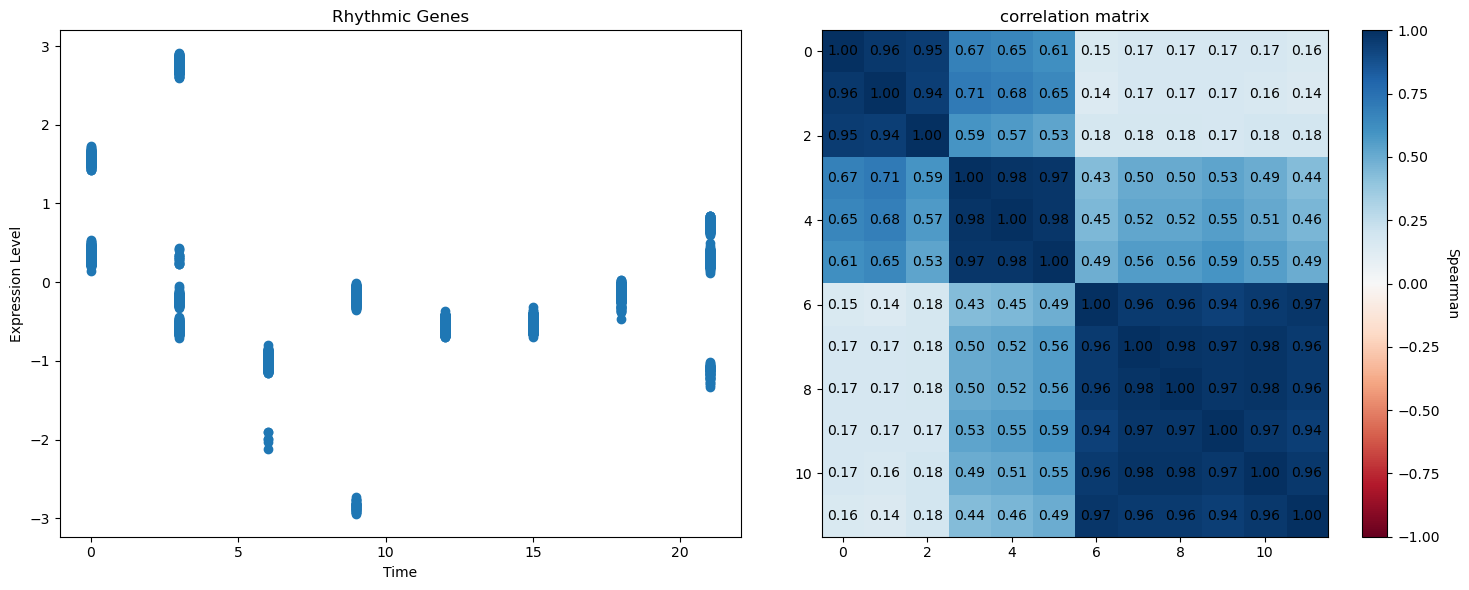

In [14]:
import scipy
from matplotlib.colors import Normalize

emat = adata.X.T[n_genes:n_genes + 12,:]

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot rhythmic genes
axes[0].set_title('Rhythmic Genes')
for i in range(0,1):
    axes[0].scatter(adata.obs['timepoints'], emat[i, :], label=f'Gene_{i + 1}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Expression Level')

# Plot correlation matrix:
corr_mat = np.array(scipy.stats.spearmanr(emat.T))[0,:,:]

axes[1].set_title('correlation matrix')
im = axes[1].imshow(corr_mat, cmap = "RdBu",  norm=Normalize(vmin=-1, vmax=1))
# Add the color bar
cbar = axes[1].figure.colorbar(im, ax = axes[1])
#axes[1].legend()
cbar.ax.set_ylabel("Spearman", rotation = -90, va = "bottom")

# Add text annotations to each box
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        text = axes[1].text(j, i, f'{corr_mat[i, j]:.2f}',
                           ha="center", va="center", color="black")
        
plt.tight_layout()

# Show the plot
plt.show()


**Show Reference Matrix**

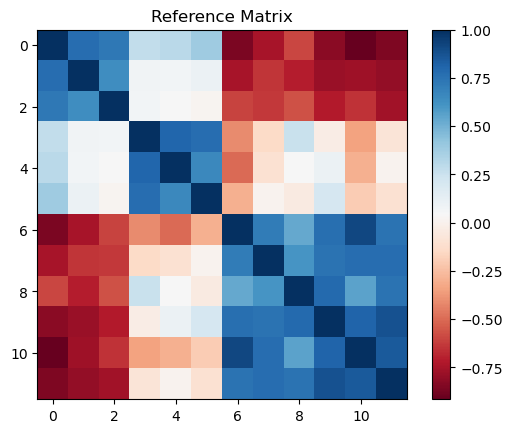

CCD leiden: 5.049597379758185
CCD louvain: 5.049597379758185
5.049597379758185


In [15]:
import math
refmat = np.array([[1.0000000,  0.77547090,  0.72492855,  0.27817942, -0.63637681, -0.60375141, -0.8614806, -0.7471112, -0.59455286, -0.8234182, -0.9146447, -0.8473980],
                        [0.7754709,  1.00000000,  0.63439613,  0.07402797, -0.62632300, -0.34987550, -0.7461844, -0.6450780, -0.70865725, -0.7845410, -0.7654845, -0.7983427],
                        [0.7249286,  0.63439613,  1.00000000,  0.06541974, -0.59727560, -0.30024636, -0.6031795, -0.6364953, -0.56958405, -0.7144612, -0.6455111, -0.7595101],
                        [0.2781794,  0.07402797,  0.06541974,  1.00000000, -0.01245765, -0.72253596, -0.4099044, -0.1411756,  0.25538496, -0.0252816, -0.3401805, -0.0781101],
                        [-0.6363768, -0.62632300, -0.59727560, -0.01245765,  1.00000000,  0.28367324,  0.6234166,  0.6454257,  0.59510653,  0.6712806,  0.6618797,  0.7597038],
                        [-0.6037514, -0.34987550, -0.30024636, -0.72253596,  0.28367324,  1.00000000,  0.6772739,  0.4242223, -0.06776682,  0.3366267,  0.6955807,  0.3810191],
                        [-0.8614806, -0.74618443, -0.60317949, -0.40990436,  0.62341661,  0.67727389,  1.0000000,  0.7132144,  0.52923596,  0.7673822,  0.9111478,  0.7487607],
                        [-0.7471112, -0.64507795, -0.63649530, -0.14117556,  0.64542570,  0.42422234,  0.7132144,  1.0000000,  0.60794410,  0.7467579,  0.7732704,  0.7756198],
                        [-0.5945529, -0.70865725, -0.56958405,  0.25538496,  0.59510653, -0.06776682,  0.5292360,  0.6079441,  1.00000000,  0.7868302,  0.5543211,  0.7530874],
                        [-0.8234182, -0.78454102, -0.71446119, -0.02528160,  0.67128060,  0.33662668,  0.7673822,  0.7467579,  0.78683019,  1.0000000,  0.8117621,  0.8738338],
                        [-0.9146447, -0.76548454, -0.64551113, -0.34018047,  0.66187971,  0.69558073,  0.9111478,  0.7732704,  0.55432112,  0.8117621,  1.0000000,  0.8443479],
                        [-0.8473980, -0.79834269, -0.75951011, -0.07811010,  0.75970381,  0.38101906,  0.7487607,  0.7756198,  0.75308740,  0.8738338,  0.8443479,  1.0000000]])
refmat = np.array([[1,	0.7754709,	0.72492855,	0.27817942,	0.3,	-0.60375141,	-0.8614806,	-0.7471112,	-0.59455286,	-0.8234182,	-0.9146447,	-0.847398],
                    [0.7754709,	1,	0.63439613,	0.07402797,	0.07,	-0.3498755,	-0.7461844,	-0.645078,	-0.70865725,	-0.784541,	-0.7654845,	-0.7983427],
                    [0.7249286,	0.63439613,	1,	0.06541974,	0.05,	-0.30024636,	-0.6031795,	-0.6364953,	-0.56958405,	-0.7144612,	-0.6455111,	-0.7595101],
                    [0.2781794,	0.07402797,	0.06541974,	1,	0.8,	-0.72253596,	-0.4099044,	-0.1411756,	0.25538496,	-0.0252816,	-0.3401805,	-0.0781101],
                    [0.3,	0.07,	0.05,	0.8,	1,	-0.7,	-0.5,	-0.1,	0.05,	0.1,	-0.3,	0.01],
                    [-0.6037514,	-0.3498755,	-0.30024636,	-0.72253596,	-0.7,	1,	0.6772739,	0.4242223,	-0.06776682,	0.3366267,	0.6955807,	0.3810191],
                    [-0.8614806,	-0.74618443,	-0.60317949,	-0.40990436,	-0.5,	0.67727389,	1,	0.7132144,	0.52923596,	0.7673822,	0.9111478,	0.7487607],
                    [-0.7471112,	-0.64507795,	-0.6364953,	-0.14117556,	-0.1,	0.42422234,	0.7132144,	1,	0.6079441,	0.7467579,	0.7732704,	0.7756198],
                    [-0.5945529,	-0.70865725,	-0.56958405,	0.25538496,	0.05,	-0.06776682,	0.529236,	0.6079441,	1,	0.7868302,	0.5543211,	0.7530874],
                    [-0.8234182,	-0.78454102,	-0.71446119,	-0.0252816,	0.1,	0.33662668,	0.7673822,	0.7467579,	0.78683019,	1,	0.8117621,	0.8738338],
                    [-0.9146447,	-0.76548454,	-0.64551113,	-0.34018047,	-0.3,	0.69558073,	0.9111478,	0.7732704,	0.55432112,	0.8117621,	1,	0.8443479],
                    [-0.847398,	-0.79834269,	-0.75951011,	-0.0781101,	0.01,	0.38101906,	0.7487607,	0.7756198,	0.7530874,	0.8738338,	0.8443479,	1]])
refmat = np.array([[1, 0.7754709, 0.72492855, 0.27817942, 0.3, 0.38, -0.8614806, -0.7471112, -0.59455286, -0.8234182, -0.9146447, -0.847398],
                    [0.7754709, 1, 0.63439613, 0.07402797, 0.07, 0.1, -0.7461844, -0.645078, -0.70865725, -0.784541, -0.7654845, -0.7983427],
                    [0.7249286, 0.63439613, 1, 0.06541974, 0.05, 0.02, -0.6031795, -0.6364953, -0.56958405, -0.7144612, -0.6455111, -0.7595101],
                    [0.2781794, 0.07402797, 0.06541974, 1, 0.8, 0.77, -0.4099044, -0.1411756, 0.25538496, -0.0252816, -0.3401805, -0.0781101],
                    [0.3, 0.07, 0.05, 0.8, 1, 0.66, -0.5, -0.1, 0.05, 0.1, -0.3, 0.01],
                    [0.38, 0.1, 0.02, 0.77, 0.66, 1, -0.3, 0.01, -0.04, 0.2, -0.2, -0.1],
                    [-0.8614806, -0.74618443, -0.60317949, -0.40990436, -0.5, -0.3, 1, 0.7132144, 0.52923596, 0.7673822, 0.9111478, 0.7487607],
                    [-0.7471112, -0.64507795, -0.6364953, -0.14117556, -0.1, 0.01, 0.7132144, 1, 0.6079441, 0.7467579, 0.7732704, 0.7756198],
                    [-0.5945529, -0.70865725, -0.56958405, 0.25538496, 0.05, -0.04, 0.529236, 0.6079441, 1, 0.7868302, 0.5543211, 0.7530874],
                    [-0.8234182, -0.78454102, -0.71446119, -0.0252816, 0.1, 0.2, 0.7673822, 0.7467579, 0.78683019, 1, 0.8117621, 0.8738338],
                    [-0.9146447, -0.76548454, -0.64551113, -0.34018047, -0.3, -0.2, 0.9111478, 0.7732704, 0.55432112, 0.8117621, 1, 0.8443479],
                    [-0.847398, -0.79834269, -0.75951011, -0.0781101, 0.01, -0.1, 0.7487607, 0.7756198, 0.7530874, 0.8738338, 0.8443479, 1]])
plt.imshow( refmat, cmap = "RdBu" )
plt.colorbar()
plt.title( "Reference Matrix" )
plt.show()
# print(emat)
print("CCD leiden: {}".format(leidenalg.calcCCD(refmat, emat)))
print("CCD louvain: {}".format(louvain.calcCCD(refmat, emat)))

def calcDist(r1, r2):
    tmp = r1-r2
    tmp = tmp ** 2
    return(math.sqrt(np.sum(tmp)))
def calcCCDsimple(ref, emat):
    upper_ref = np.triu(ref)
    corr_mat = np.array(scipy.stats.spearmanr(emat.T))[0,:,:]
    upper_corrmat = np.triu(corr_mat)
    return(calcDist(upper_corrmat, upper_ref))

print(calcCCDsimple(refmat, emat))

In [16]:
import igraph as ig
emat = adata.X.T[n_genes:n_genes + 12,:]
subjects = subjects.astype(np.int32)
subjects = subjects.reshape(1, -1)
print(subjects.shape)

(1, 5000)


In [17]:
_, G2 = cluster_louvain(adata, emat, refmat, subjects,  partition_type= louvain.ModularityVertexPartition)  # You can adjust the 'resolution' parameter
membership_louvainStock = [int(i) for i in adata.obs['louvainccd'].to_list()]
# _plot(G2, membership_louvainStock, draw = "kk")

subject info shape (1, 5000), subject info dtype int32. 
Using partition class:  <class 'louvain.VertexPartition.ModularityVertexPartition'>
nodes: 5000
nodes: 8
nodes: 5


In [18]:
# Perform Louvain clustering
t0 = time.time()
_, G = cluster_louvain(adata, emat, refmat, sample_ids= subjects, partition_type= louvain.ccdModularityVertexPartition)  # You can adjust the 'resolution' parameter
membership = [int(i) for i in adata.obs['louvainccd'].to_list()]
t1 = time.time()
print("time: {}".format(t1-t0))
# _plot(G, membership, draw = "kk")


subject info shape (1, 5000), subject info dtype int32. 
Using partition class:  <class 'louvain.VertexPartition.ccdModularityVertexPartition'>
Processing ccdModularityVertexPartition instance
nodes: 5000
nodes: 8
v: 7
old comm:7 --> new comm: 1
Nodes in v: 41
Nodes in old comm v: 41 ccd(): 0
Nodes in new comm NO v: 905 ccd(): -198.808
Nodes in old comm NO v: 0 ccd(): 0
Nodes in new comm v: 946 ccd(): -206.138
CCD result: -0.0077491
v: 1
old comm:1 --> new comm: 0
Nodes in v: 905
Nodes in old comm v: 905 ccd(): -198.808
Nodes in new comm NO v: 963 ccd(): 621.78
Nodes in old comm NO v: 0 ccd(): 0
Nodes in new comm v: 1868 ccd(): 204.492
CCD result: -0.11696
v: 1
old comm:1 --> new comm: 2
Nodes in v: 905
Nodes in old comm v: 905 ccd(): -198.808
Nodes in new comm NO v: 897 ccd(): 735.89
Nodes in old comm NO v: 0 ccd(): 0
Nodes in new comm v: 1802 ccd(): 91.3381
CCD result: -0.247361
v: 1
old comm:1 --> new comm: 3
Nodes in v: 905
Nodes in old comm v: 905 ccd(): -198.808
Nodes in new comm

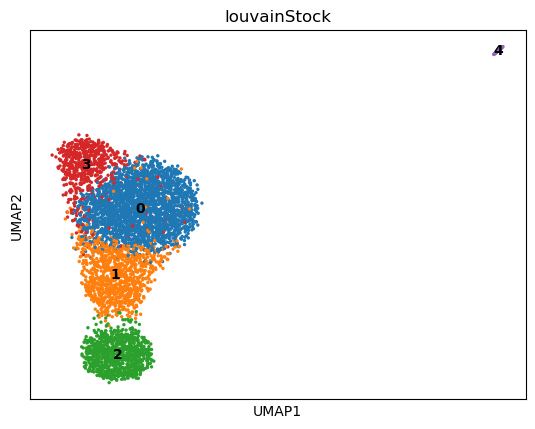

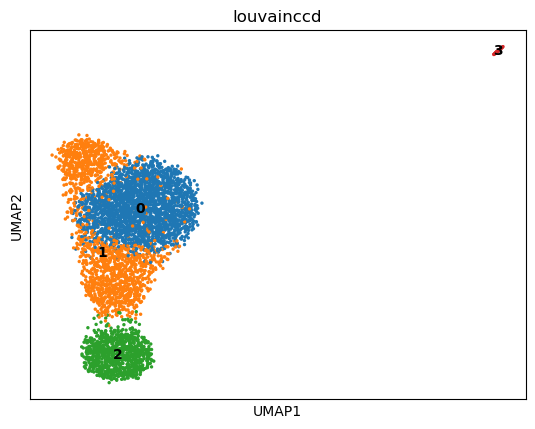

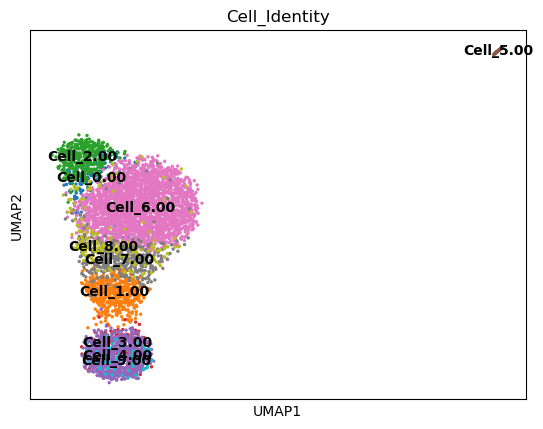

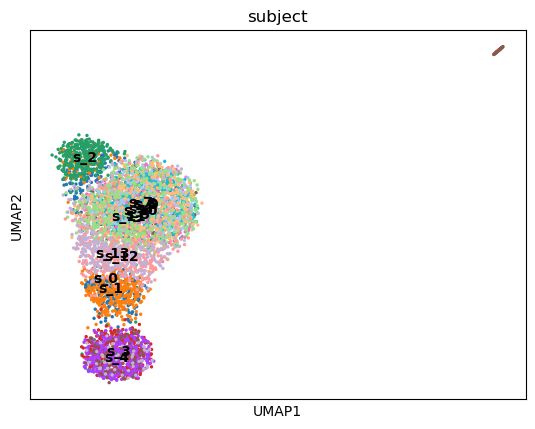

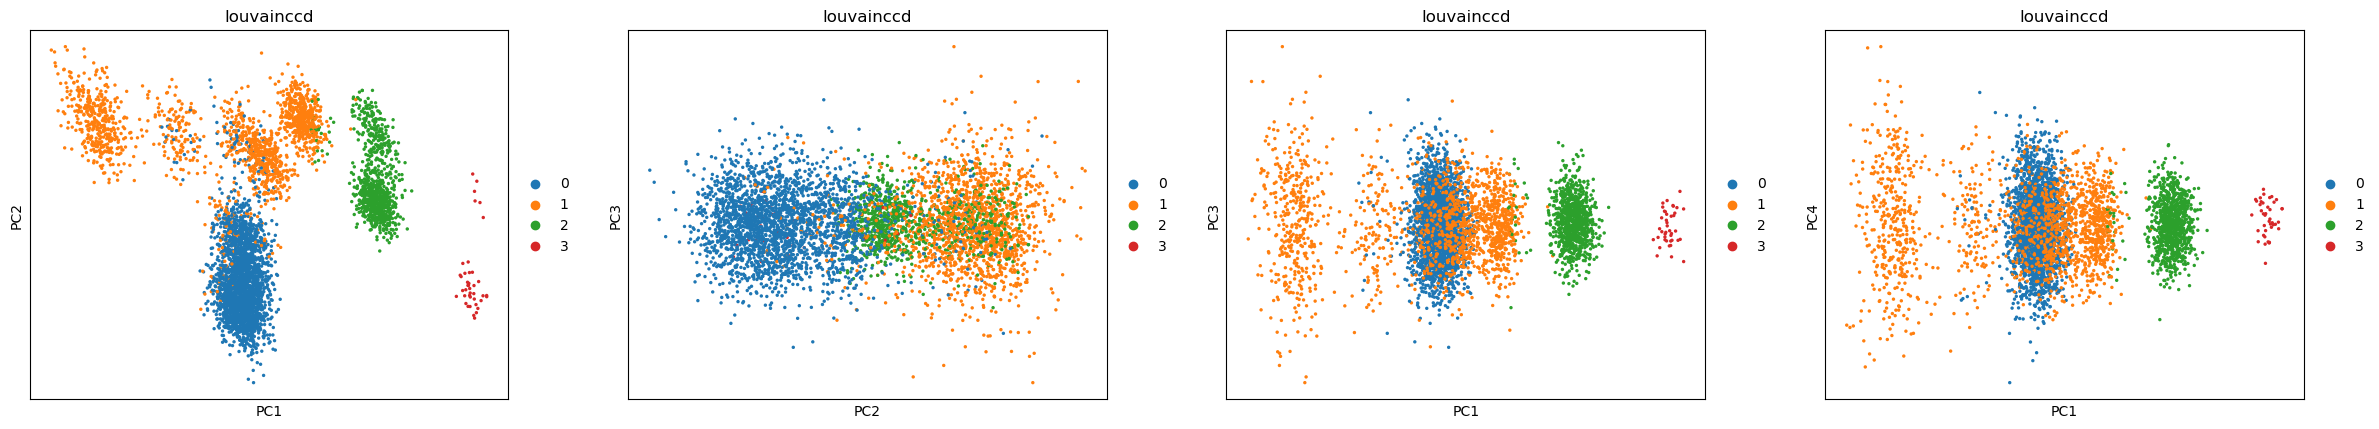

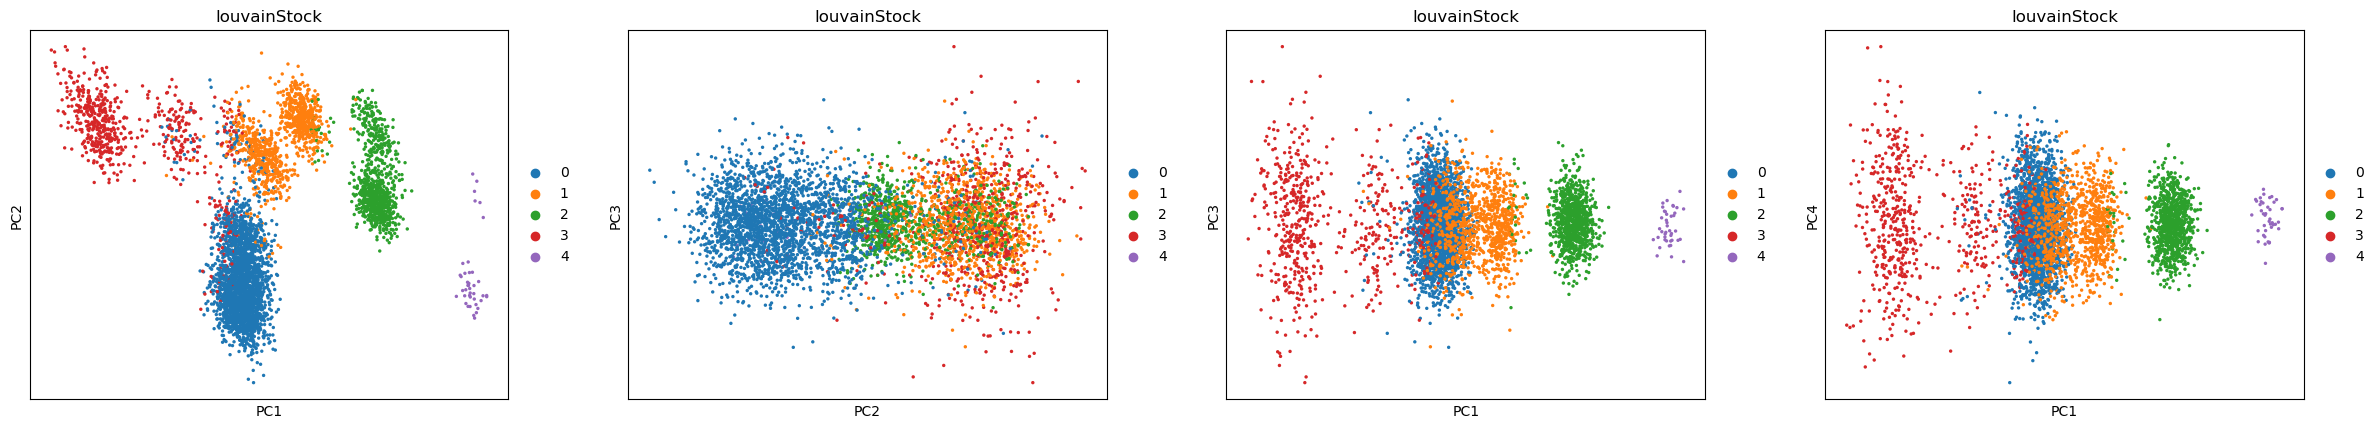

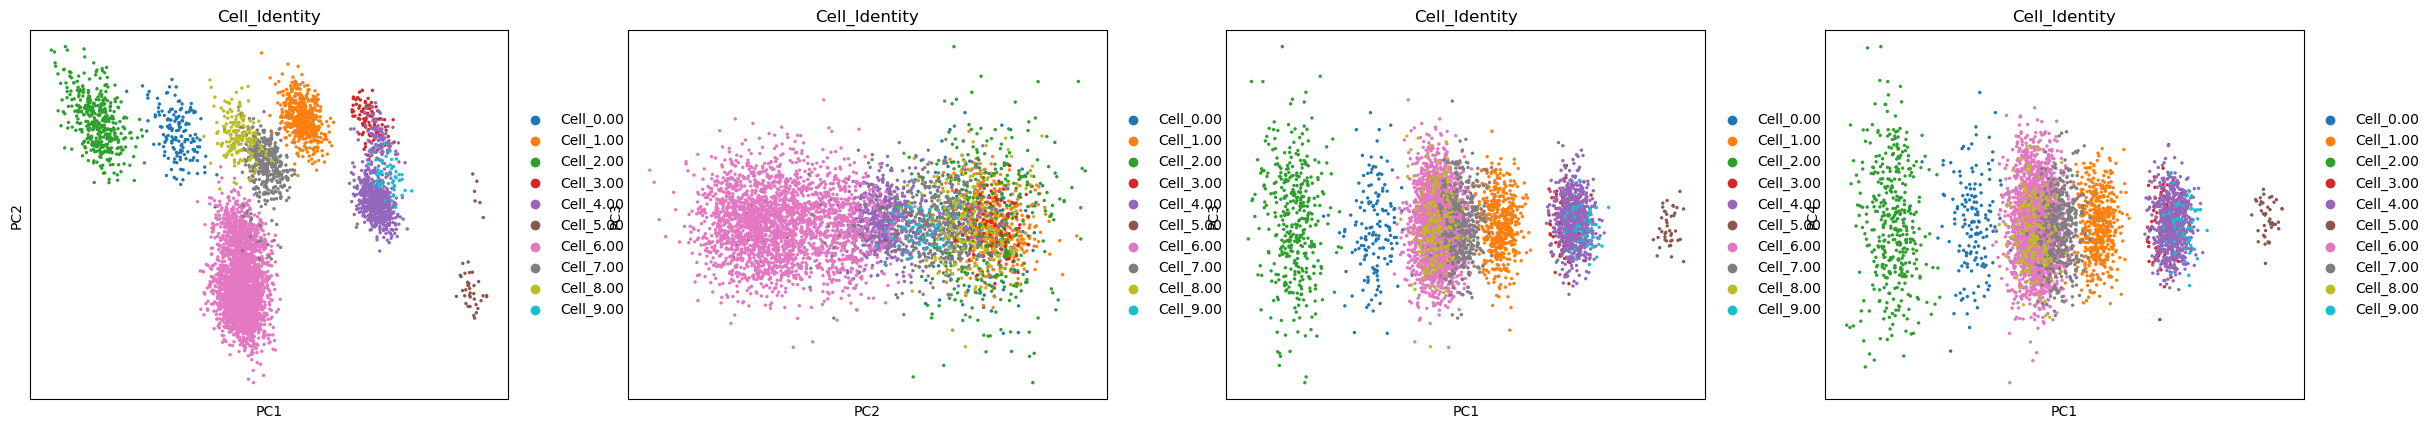

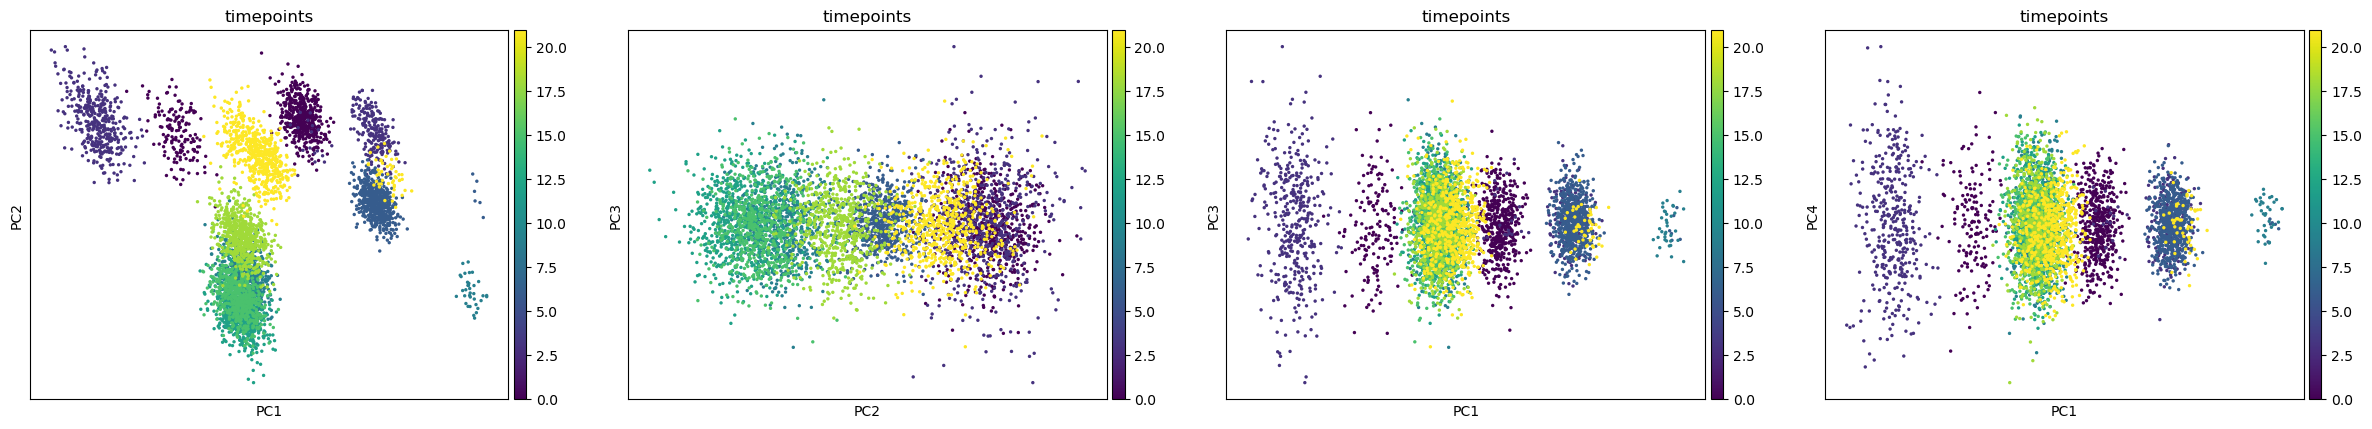

In [19]:
# Assuming you have an 'adata' object with Louvain cluster assignments
import warnings
# Suppress specific warnings
# Suppress all warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Calculate UMAP
    sc.tl.umap(adata)
    pcs_to_plot = ['1,2', '2,3', '1,3', '1, 4']
    # Plot UMAP with Louvain clusters
    adata.obs['louvainStock'] = [str(i) for i in membership_louvainStock]
    sc.pl.umap(adata, color='louvainStock', legend_loc='on data')
    sc.pl.umap(adata, color='louvainccd', legend_loc='on data')
    sc.pl.umap(adata, color='Cell_Identity', legend_loc='on data')
    sc.pl.umap(adata, color = 'subject', legend_loc = 'on data')
    sc.pl.pca(adata, color= 'louvainccd' , components = pcs_to_plot, show=True)
    adata.obs['louvainStock'] = [str(i) for i in membership_louvainStock]
    sc.pl.pca(adata, color = 'louvainStock', components = pcs_to_plot,  show = True)
    sc.pl.pca(adata, color='Cell_Identity', components=pcs_to_plot, show=True)
    sc.pl.pca(adata, color='timepoints', components=pcs_to_plot, show=True)


Cluster 0 contains 10 samples
[[ 0  0  0 ... 13 13 13]]
Cluster 1 contains 13 samples
[[ 0  0  0 ... 13 13 13]]
Cluster 2 contains 7 samples
[[ 0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2
   2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
   2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
   3  3  3  3  3  3  3  3  3  3  3  3  3  3  

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

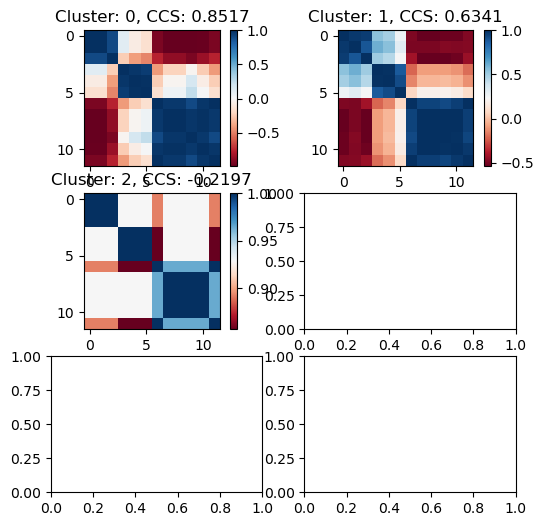

In [20]:
import matplotlib.pyplot as plt

def sumByGroup(matrix, groups):
    # Convert inputs to numpy arrays for easier manipulation
    matrix = np.array(matrix)
    groups = np.array(groups).flatten()
    
    # Get the unique groups
    unique_groups = np.unique(groups)
    
    # Initialize the result matrix with zeros
    result = np.zeros((matrix.shape[0], len(unique_groups)))
    
    # Sum the columns of the matrix according to the groups
    for i, group in enumerate(unique_groups):
        result[:, i] = matrix[:, groups == group].sum(axis=1)
    
    return result

def get_corgram(membership, clusterID):
    cluster_A_cells = [i for i in range(len(membership)) if membership[i] == clusterID]
    cluster_A_emat = adata.X.T[n_genes:n_genes + 12, cluster_A_cells]
    clusterA_groups = [subjects[0,i] for i in cluster_A_cells]
    pseudoBulk = sumByGroup(cluster_A_emat, clusterA_groups)
    print("Cluster {} contains {} samples".format(clusterID, len(np.unique(clusterA_groups))))
    print(np.array(clusterA_groups).astype(np.int32).reshape(1, -1))
    ccs = louvain.calcCCS(refmat, cluster_A_emat, np.array(clusterA_groups).astype(np.int32).reshape(1, -1))
    # Get correlation matrix:
    corr_mat = np.array(scipy.stats.spearmanr(pseudoBulk.T))[0,:,:]
    return(corr_mat, ccs)

def plot_corgrams(membership):
    num_clusters = len(np.unique(membership))
    cols = 2
    rows = math.ceil((num_clusters+1) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6, rows*2))
    # Flatten the axes array
    axes = axes.flatten()

    # Iterate over the list and plot each item in a subplot
    for i in range(num_clusters):
        corgram, ccs = get_corgram(membership, i)
        heatmap = axes[i].imshow(corgram, cmap = "RdBu")
        axes[i].set_title('Cluster: {}, CCS: {:.4f}'.format(i, ccs))
        fig.colorbar(heatmap, ax=axes[i])

    heatmap_ref = axes[-1].imshow(refmat, cmap = "RdBu")
    axes[-1].set_title('Reference')
    fig.colorbar(heatmap_ref, ax=axes[-1])

    # # Hide any unused subplots
    # for j in range(i + 1, len(axes)):
    #     fig.delaxes(axes[j])

    # Display the plot
    plt.tight_layout()
    plt.show()

plot_corgrams(membership)
plot_corgrams(membership_louvainStock)

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score

ari1 = adjusted_rand_score(membership,adata2.obs['Cell_Identity'])
ari2 = adjusted_rand_score(membership_louvainStock,adata2.obs['Cell_Identity'])
# Print the ARI
print("Adjusted Rand Index(my_alg, ground truth):", ari1)
print("Adjusted Rand Index(LouvainStock, ground truth):", ari2)

